# GAT4 seed replicates: base versus full features

Six completed runs: **base/full × seeds 7, 17, 27**, evaluated on a shared target split. This notebook reads the downloaded prediction/history CSVs and a checkpoint-metadata snapshot; it never changes run artifacts or loads model weights.

The full configuration adds **interface-node degree, log-transformed Voronoi contact area, and its missing mask**. This comparison does not isolate the effect of area alone. These runs used **adaptive loss-share weighting**, not the fixed-weight objective planned for the extension experiments.

We evaluate score accuracy, within-target ranking, top-structure selection, calibration, seed variation, and training behavior. Test metrics describe the checkpoints selected by validation; no test-based checkpoint or seed selection is performed.

In [1]:
from pathlib import Path
import hashlib
import json
import re
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, pearsonr
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
get_ipython().run_line_magic('matplotlib', 'inline')

# Works when launched from the repository, gate_run, or seed_replicates.
candidates = [Path.cwd(), *Path.cwd().parents]
GATE_DIR = next((p for parent in candidates for p in (parent, parent / 'gate_run')
                 if (p / 'seed_replicates/shared_target_splits.json').is_file()), None)
if GATE_DIR is None:
    raise FileNotFoundError('Set GATE_DIR to the repository gate_run directory.')
RUN_ROOT = GATE_DIR / 'seed_replicates'
EXPORT = GATE_DIR / 'seed_replicates_analysis'
EXPORT.mkdir(exist_ok=True)
metadata = json.loads((GATE_DIR / 'seed_replicates_metadata.json').read_text())
SEEDS = [7, 17, 27]
CONFIGS = ['base', 'full']
COLORS = {'base': '#585858', 'full': '#247ba0'}
LABELS = {'base': 'Base', 'full': 'Full features'}
mpl.rcParams.update({'font.family': 'serif', 'font.serif': ['DejaVu Serif'],
                     'mathtext.fontset': 'cm', 'text.usetex': False,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'legend.frameon': False, 'figure.dpi': 110, 'savefig.dpi': 180})
pd.set_option('display.max_columns', 25)

def savefig(fig, name):
    fig.savefig(EXPORT / f'{name}.png', bbox_inches='tight')
    fig.savefig(EXPORT / f'{name}.pdf', bbox_inches='tight')
    plt.show()

def export(frame, name):
    frame.to_csv(EXPORT / f'{name}.csv', index=False)

print('Input:', RUN_ROOT)
print('Figures and tables:', EXPORT)

Input: /scratch/PPI-graph_autoencoder/gate_run/seed_replicates
Figures and tables: /scratch/PPI-graph_autoencoder/gate_run/seed_replicates_analysis


## Validate the experiment and its shared cohort

All runs must have identical `(target_id, graph_name)` keys and labels. Missing runs, duplicate keys, nonfinite predictions, metadata hash mismatches, and split overlap stop the analysis rather than silently changing the cohort. The checkpoint snapshot includes hashes of the original CSVs and checkpoint files.

In [2]:
predictions, histories, inventory = {}, {}, []
reference = None
for config in CONFIGS:
    for seed in SEEDS:
        run = f'gat4_residual_{config}_seed{seed}'
        directory = RUN_ROOT / run
        meta = metadata[run]
        for filename, expected_hash in meta['sha256'].items():
            if hashlib.sha256((directory / filename).read_bytes()).hexdigest() != expected_hash:
                raise ValueError(f'{run}/{filename}: changed since checkpoint metadata was extracted')
        frame = pd.read_csv(directory / 'test_predictions.csv')
        history = pd.read_csv(directory / 'loss_history.csv')
        if frame.duplicated(['target_id', 'graph_name']).any():
            raise ValueError(f'{run}: duplicate predictions')
        if not np.isfinite(frame[['true_target', 'predicted_target']].to_numpy()).all():
            raise ValueError(f'{run}: nonfinite predictions')
        if not frame.true_target.between(0, 1).all():
            raise ValueError(f'{run}: invalid DockQ labels')
        frame = frame.sort_values(['target_id', 'graph_name']).reset_index(drop=True)
        identity = frame[['target_id', 'graph_name', 'true_target']]
        if reference is None:
            reference = identity
        elif not reference.equals(identity):
            raise ValueError(f'{run}: cohort or labels differ; a paired analysis is not valid')
        if history.epoch.duplicated().any() or not history.epoch.is_monotonic_increasing:
            raise ValueError(f'{run}: invalid epoch history')
        if len(history) != meta['args']['epochs']:
            raise ValueError(f'{run}: incomplete epoch history')
        best_row = history.loc[history.epoch.eq(meta['best_epoch'])].iloc[0]
        if not np.isclose(best_row.val_target_mse, meta['best_metric_value']):
            raise ValueError(f'{run}: checkpoint/history validation metric mismatch')
        predictions[config, seed] = frame
        histories[config, seed] = history
        inventory.append(dict(config=config, seed=seed, graphs=len(frame), targets=frame.target_id.nunique(),
            epochs=len(history), checkpoint_epoch=meta['best_epoch'], checkpoint_metric=meta['best_metric'],
            checkpoint_val_mse=meta['best_metric_value'], loss_mode=meta['args']['loss_weight_mode'],
            learning_rate=meta['args']['lr'], batch_size=meta['args']['batch_size']))
inventory = pd.DataFrame(inventory)
splits = json.loads((RUN_ROOT / 'shared_target_splits.json').read_text())['splits']
split_sets = {name: set(info.get('targets', [Path(p).stem for p in info['paths']])) for name, info in splits.items()}
assert not any(split_sets[a] & split_sets[b] for a, b in [('train','val'), ('train','test'), ('val','test')])
assert set(reference.target_id) == split_sets['test'], 'Test targets differ from shared split'
display(inventory)
export(inventory, 'run_inventory')
print(f'Exact paired cohort: {len(reference):,} graphs / {reference.target_id.nunique()} test targets.')
feature_table = pd.DataFrame([dict(config=c,
    node_features=', '.join(metadata[f'gat4_residual_{c}_seed7']['node_features']),
    edge_features=', '.join(metadata[f'gat4_residual_{c}_seed7']['edge_features']),
    transforms=str(metadata[f'gat4_residual_{c}_seed7']['edge_feature_transforms'])) for c in CONFIGS])
display(feature_table)
export(feature_table, 'feature_definitions')

,config,seed,graphs,targets,epochs,checkpoint_epoch,checkpoint_metric,checkpoint_val_mse,loss_mode,learning_rate,batch_size
0,base,7,30466,25,50,1,target_mse,0.105898,shares,0.0003,16
1,base,17,30466,25,50,1,target_mse,0.111926,shares,0.0003,16
2,base,27,30466,25,50,1,target_mse,0.106201,shares,0.0003,16
3,full,7,30466,25,50,6,target_mse,0.106597,shares,0.0003,16
4,full,17,30466,25,50,1,target_mse,0.104374,shares,0.0003,16
5,full,27,30466,25,50,6,target_mse,0.099076,shares,0.0003,16


Exact paired cohort: 30,466 graphs / 25 test targets.


,config,node_features,edge_features,transforms
0,base,"aa_type, chain, interface_nodes, rsasa_i","interface_edges, ca_dist",{}
1,full,"aa_type, chain, interface_nodes, rsasa_i, inte...","interface_edges, ca_dist, voronoi_contact_area...",{'voronoi_contact_area': 'log1p'}


## Metrics: score accuracy and within-target selection

Pooled metrics weight every graph equally; **macro metrics weight each target equally**. Spearman is calculated separately within each target before averaging. Top-1 is the actual DockQ of the highest predicted structure; top-5/top-10 are the best actual DockQ among the top predicted candidates (assuming a subsequent way to identify the best). Regret is `best available DockQ − top-1 DockQ`; lower is better. Prediction ties use graph-name ordering.

The random-selection reference is the mean true DockQ within each target. The constant-mean MSE below uses the **test mean only as a descriptive reference**, not a deployable baseline fitted on test labels.

In [3]:
def correlation(y, p, rank=False):
    if len(y) < 2 or np.std(y) == 0 or np.std(p) == 0:
        return np.nan
    return float((spearmanr if rank else pearsonr)(y, p).statistic)

per_target_rows, run_rows = [], []
for (config, seed), frame in predictions.items():
    start = len(per_target_rows)
    for target, group in frame.groupby('target_id', sort=True):
        y, p = group.true_target.to_numpy(), group.predicted_target.to_numpy()
        order = np.argsort(-p, kind='stable')
        per_target_rows.append(dict(config=config, seed=seed, target=target, n=len(group),
            mse=np.mean((p-y)**2), mae=np.mean(abs(p-y)), bias=np.mean(p-y),
            spearman=correlation(y,p,True), pearson=correlation(y,p),
            top1=y[order[0]], top5=y[order[:5]].max(), top10=y[order[:10]].max(),
            oracle=y.max(), random=y.mean(), regret=y.max()-y[order[0]]))
    macro = pd.DataFrame(per_target_rows[start:])
    y, p = frame.true_target.to_numpy(), frame.predicted_target.to_numpy()
    mse = np.mean((p-y)**2)
    run_rows.append(dict(config=config, seed=seed, mse=mse, rmse=np.sqrt(mse),
        mae=np.mean(abs(p-y)), r2=1-mse/np.var(y), pearson=correlation(y,p),
        spearman=correlation(y,p,True), bias=np.mean(p-y), macro_mse=macro.mse.mean(),
        macro_spearman=macro.spearman.mean(), defined_target_correlations=macro.spearman.notna().sum(),
        top1=macro.top1.mean(), top5=macro.top5.mean(), top10=macro.top10.mean(),
        regret=macro.regret.mean(), oracle=macro.oracle.mean(), random=macro.random.mean(),
        outside_0_1=int(((p<0)|(p>1)).sum())))
per_target = pd.DataFrame(per_target_rows)
metrics = pd.DataFrame(run_rows)
display(metrics.round(4))
export(metrics, 'metrics_by_run')
export(per_target, 'metrics_by_target_and_seed')
summary_columns = ['rmse','mae','r2','macro_mse','macro_spearman','top1','top5','regret','bias']
seed_summary = metrics.groupby('config')[summary_columns].agg(['mean','std'])
display(seed_summary.round(4))
seed_summary.to_csv(EXPORT / 'seed_mean_and_sd.csv')
print('SD is variation across three training seeds on the same split, not three independent test cohorts.')
print('Descriptive test-mean constant MSE:', np.var(reference.true_target))

,config,seed,mse,rmse,mae,r2,pearson,spearman,bias,macro_mse,macro_spearman,defined_target_correlations,top1,top5,top10,regret,oracle,random,outside_0_1
0,base,7,0.0760,0.2757,0.1890,0.2170,0.5871,0.5881,-0.0997,0.0765,0.6502,25,0.4247,0.5650,0.6223,0.4908,0.9154,0.3315,42
1,base,17,0.0835,0.2889,0.1986,0.1398,0.5979,0.6459,-0.1443,0.0842,0.7150,25,0.3408,0.5904,0.6912,0.5746,0.9154,0.3315,55
2,base,27,0.0771,0.2776,0.1901,0.2061,0.6070,0.6611,-0.1225,0.0778,0.6791,25,0.3647,0.5532,0.5813,0.5508,0.9154,0.3315,6
3,full,7,0.0837,0.2894,0.1984,0.1373,0.6087,0.5508,-0.1504,0.0842,0.6591,25,0.4812,0.6362,0.6781,0.4343,0.9154,0.3315,36
4,full,17,0.0842,0.2902,0.1940,0.1322,0.5774,0.5956,-0.1357,0.0836,0.6503,25,0.3731,0.5444,0.6169,0.5423,0.9154,0.3315,58
5,full,27,0.0737,0.2714,0.1852,0.2409,0.6195,0.6108,-0.1149,0.0740,0.6544,25,0.4628,0.6598,0.7415,0.4526,0.9154,0.3315,1


rmse             mae              r2         macro_mse          \
          mean     std    mean     std    mean     std      mean     std   
config                                                                     
base    0.2807  0.0072  0.1926  0.0053  0.1876  0.0418    0.0795  0.0042   
full    0.2837  0.0106  0.1925  0.0068  0.1701  0.0613    0.0806  0.0057   

       macro_spearman            top1            top5          regret          \
                 mean     std    mean     std    mean     std    mean     std   
config                                                                          
base           0.6814  0.0324  0.3767  0.0432  0.5695  0.0191  0.5387  0.0432   
full           0.6546  0.0044  0.4390  0.0578  0.6135  0.0609  0.4764  0.0578   

          bias          
          mean     std  
config                  
base   -0.1221  0.0223  
full   -0.1337  0.0178

SD is variation across three training seeds on the same split, not three independent test cohorts.
Descriptive test-mean constant MSE: 0.09705441853789507


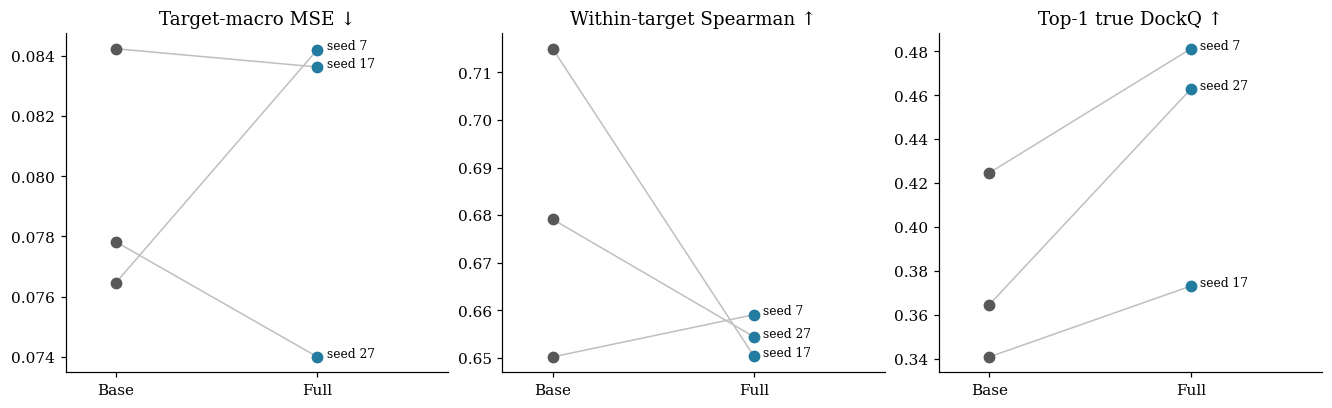

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), constrained_layout=True)
for ax, metric, title in zip(axes, ['macro_mse','macro_spearman','top1'],
                           ['Target-macro MSE ↓','Within-target Spearman ↑','Top-1 true DockQ ↑']):
    for seed in SEEDS:
        values = [metrics.loc[(metrics.config==c)&(metrics.seed==seed),metric].iloc[0] for c in CONFIGS]
        ax.plot([0,1], values, color='0.75', lw=1)
        for x,c,value in zip([0,1], CONFIGS, values):
            ax.scatter(x,value,color=COLORS[c],s=45,zorder=3)
        ax.annotate(f'seed {seed}', (1,values[1]), xytext=(6,0), textcoords='offset points',fontsize=8)
    ax.set(xticks=[0,1], xticklabels=['Base','Full'], title=title, xlim=(-.25,1.65))
savefig(fig, 'paired_seed_metrics')

## Paired uncertainty across targets

For each target, average each metric over the three seeds **before** computing the base/full difference. Bootstrap targets together across configurations (10,000 draws). Positive values always mean improvement with full features. These intervals describe target sampling uncertainty conditional on this split and these three seeds; they do not treat decoys or seeds as independent test samples. Intervals are pointwise, with no multiple-comparison correction. Target-macro MSE is the main score-error comparison; other metrics are diagnostic.

,metric,mean_improvement,ci95_low,ci95_high,improved_targets,tied_targets,targets
0,mse,-0.00111,-0.01281,0.01184,10,0,25
1,mae,0.00040,-0.01638,0.01969,11,0,25
2,spearman,-0.02683,-0.09196,0.03313,14,0,25
3,top1,0.06231,-0.00479,0.13769,14,0,25
4,top5,0.04395,-0.03218,0.12449,17,0,25
5,regret,0.06231,-0.00479,0.13769,14,0,25


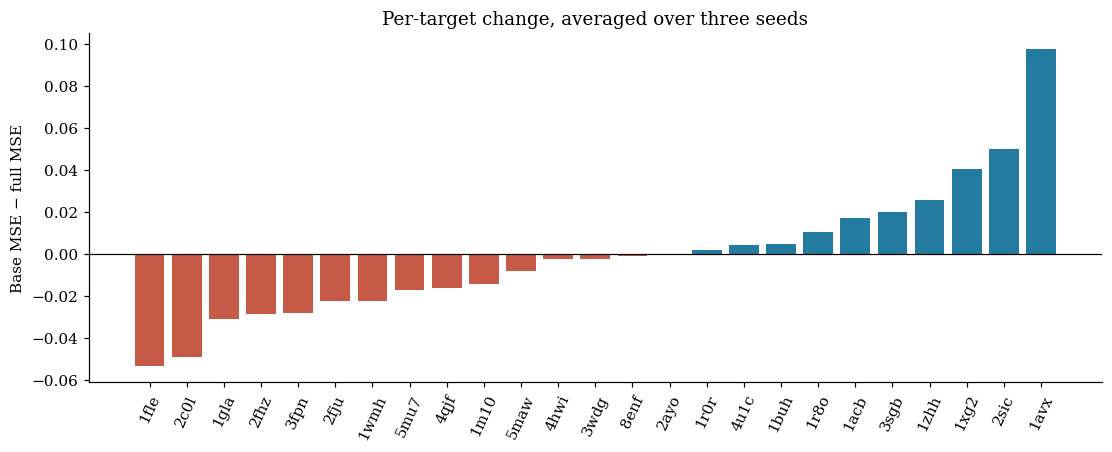

In [5]:
target_mean = per_target.groupby(['config','target']).mean(numeric_only=True)
base = target_mean.loc['base'].sort_index()
full = target_mean.loc['full'].sort_index()
assert base.index.equals(full.index)
deltas = pd.DataFrame(index=base.index)
for metric in ['mse','mae','spearman','top1','top5','regret']:
    deltas[metric] = full[metric]-base[metric] if metric in ['spearman','top1','top5'] else base[metric]-full[metric]
rng = np.random.default_rng(123)
indices = rng.integers(0, len(deltas), size=(10000,len(deltas)))
paired_rows = []
for metric in deltas:
    values = deltas[metric].to_numpy()
    if not np.isfinite(values).all():
        raise ValueError(f'Undefined {metric}; explicitly define the paired target cohort before bootstrapping')
    boot = values[indices].mean(axis=1)
    paired_rows.append(dict(metric=metric, mean_improvement=values.mean(),
        ci95_low=np.quantile(boot,.025), ci95_high=np.quantile(boot,.975),
        improved_targets=int((values>0).sum()), tied_targets=int((values==0).sum()), targets=len(values)))
paired = pd.DataFrame(paired_rows)
display(paired.round(5))
export(paired, 'paired_target_bootstrap')
export(deltas.reset_index(), 'paired_target_improvements')
fig, ax = plt.subplots(figsize=(10,4), constrained_layout=True)
ordered = deltas.mse.sort_values()
ax.bar(ordered.index, ordered, color=np.where(ordered>0,COLORS['full'],'#c65a46'))
ax.axhline(0,color='black',lw=.8)
ax.set(ylabel='Base MSE − full MSE',title='Per-target change, averaged over three seeds')
ax.tick_params(axis='x',rotation=65)
savefig(fig,'target_mse_improvements')

## Training and checkpoint selection

The exported predictions come from the **best validation checkpoint**, not necessarily epoch 50. Vertical lines mark the checkpoint epoch from saved metadata. Training improvement combined with worsening validation performance is consistent with overfitting; these histories alone cannot establish whether adaptive weighting caused it. The old runs recorded test losses during training; we do not use those curves for model selection here.

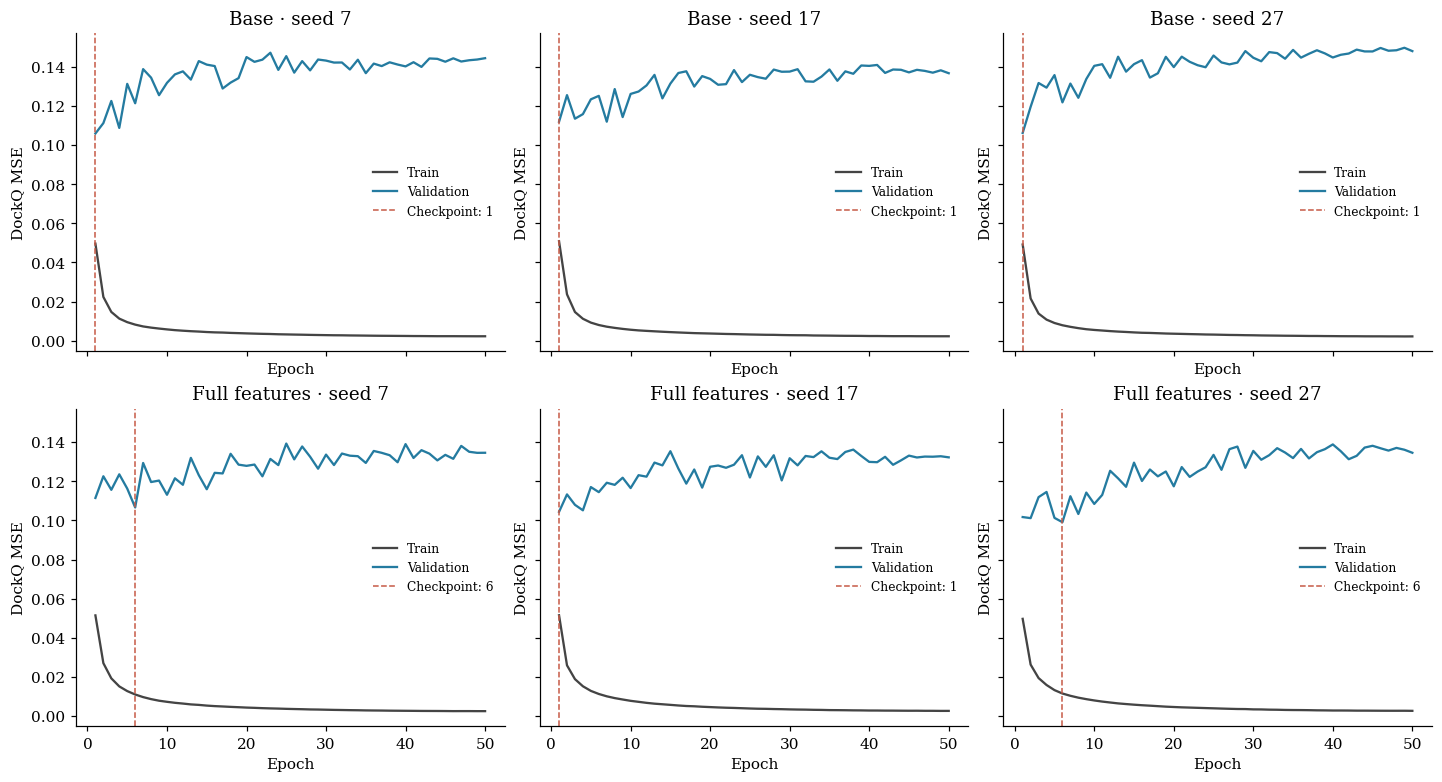

,config,seed,train_mse_first,train_mse_last,val_mse_first,val_mse_last,train_mse_reduction_percent
0,base,7,0.04960,0.00226,0.10590,0.14441,95.44447
1,base,17,0.05086,0.00226,0.11193,0.13673,95.55889
2,base,27,0.04915,0.00219,0.10620,0.14803,95.54830
3,full,7,0.05143,0.00249,0.11147,0.13457,95.16816
4,full,17,0.05150,0.00262,0.10437,0.13222,94.91821
5,full,27,0.04967,0.00264,0.10170,0.13457,94.68054


In [6]:
fig, axes = plt.subplots(2,3,figsize=(13,7),sharex=True,sharey=True,constrained_layout=True)
for row,config in enumerate(CONFIGS):
    for col,seed in enumerate(SEEDS):
        ax=axes[row,col]; h=histories[config,seed]
        best=metadata[f'gat4_residual_{config}_seed{seed}']['best_epoch']
        ax.plot(h.epoch,h.train_target_mse,label='Train',color='#444444')
        ax.plot(h.epoch,h.val_target_mse,label='Validation',color=COLORS['full'])
        ax.axvline(best,color='#c65a46',ls='--',lw=1,label=f'Checkpoint: {best}')
        ax.set(title=f'{LABELS[config]} · seed {seed}',xlabel='Epoch',ylabel='DockQ MSE')
        ax.legend(fontsize=8)
savefig(fig,'train_validation_dockq')
training_rows=[]
for (config,seed),h in histories.items():
    training_rows.append(dict(config=config,seed=seed,train_mse_first=h.train_target_mse.iloc[0],
        train_mse_last=h.train_target_mse.iloc[-1],val_mse_first=h.val_target_mse.iloc[0],
        val_mse_last=h.val_target_mse.iloc[-1],train_mse_reduction_percent=100*(1-h.train_target_mse.iloc[-1]/h.train_target_mse.iloc[0])))
training_summary=pd.DataFrame(training_rows)
display(training_summary.round(5)); export(training_summary,'training_change')

### Why can the total training loss look flat?

With adaptive loss shares, weights change during optimization. A nearly constant weighted sum does **not** imply constant raw reconstruction/regression errors. This diagnostic uses the logged raw losses, weights, and weighted contributions; it does not reconstruct epoch-average contributions by multiplying two epoch averages.

Change `DIAGNOSTIC_CONFIG` and `DIAGNOSTIC_SEED` to inspect another run.

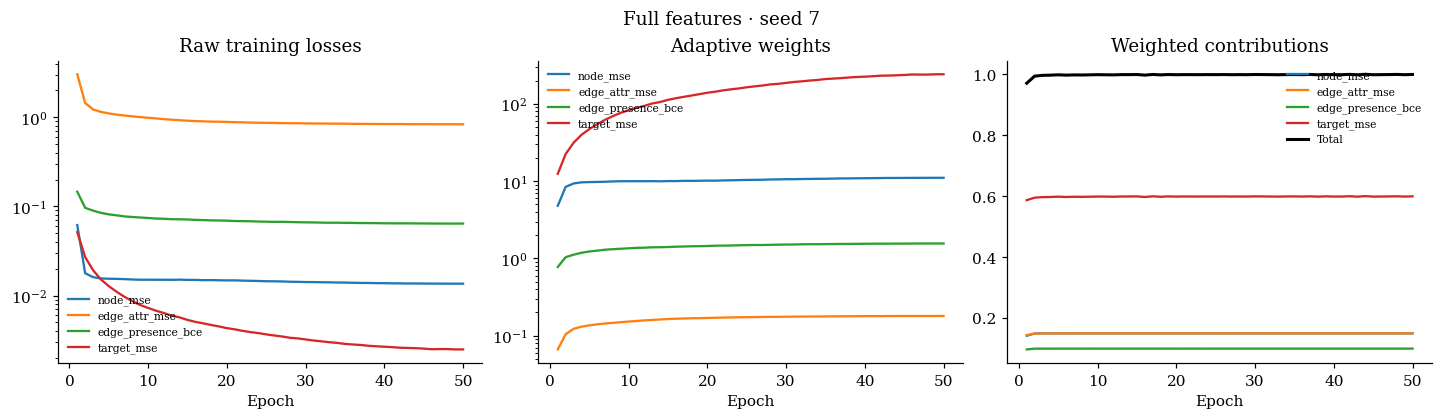

In [7]:
DIAGNOSTIC_CONFIG, DIAGNOSTIC_SEED = 'full', 7
h=histories[DIAGNOSTIC_CONFIG,DIAGNOSTIC_SEED]
terms=['node_mse','edge_attr_mse','edge_presence_bce','target_mse']
fig,axes=plt.subplots(1,3,figsize=(13,3.7),constrained_layout=True)
for term in terms:
    axes[0].plot(h.epoch,h['train_'+term],label=term)
    axes[1].plot(h.epoch,h['weight_'+term],label=term)
    axes[2].plot(h.epoch,h['train_weighted_'+term],label=term)
axes[2].plot(h.epoch,h.train_loss,color='black',lw=2,label='Total')
for ax,title in zip(axes,['Raw training losses','Adaptive weights','Weighted contributions']):
    ax.set(xlabel='Epoch',title=title); ax.legend(fontsize=7)
axes[0].set_yscale('log'); axes[1].set_yscale('log')
fig.suptitle(f'{LABELS[DIAGNOSTIC_CONFIG]} · seed {DIAGNOSTIC_SEED}')
savefig(fig,f'loss_diagnostics_{DIAGNOSTIC_CONFIG}_seed{DIAGNOSTIC_SEED}')

## Prediction spread and calibration

All six panels share axes. The diagonal is perfect agreement. The binned plot groups by **true DockQ**, exposing underprediction of high-quality structures; it is a residual diagnostic, not a reliability plot binned by predicted score. Predictions are never clipped for metrics.

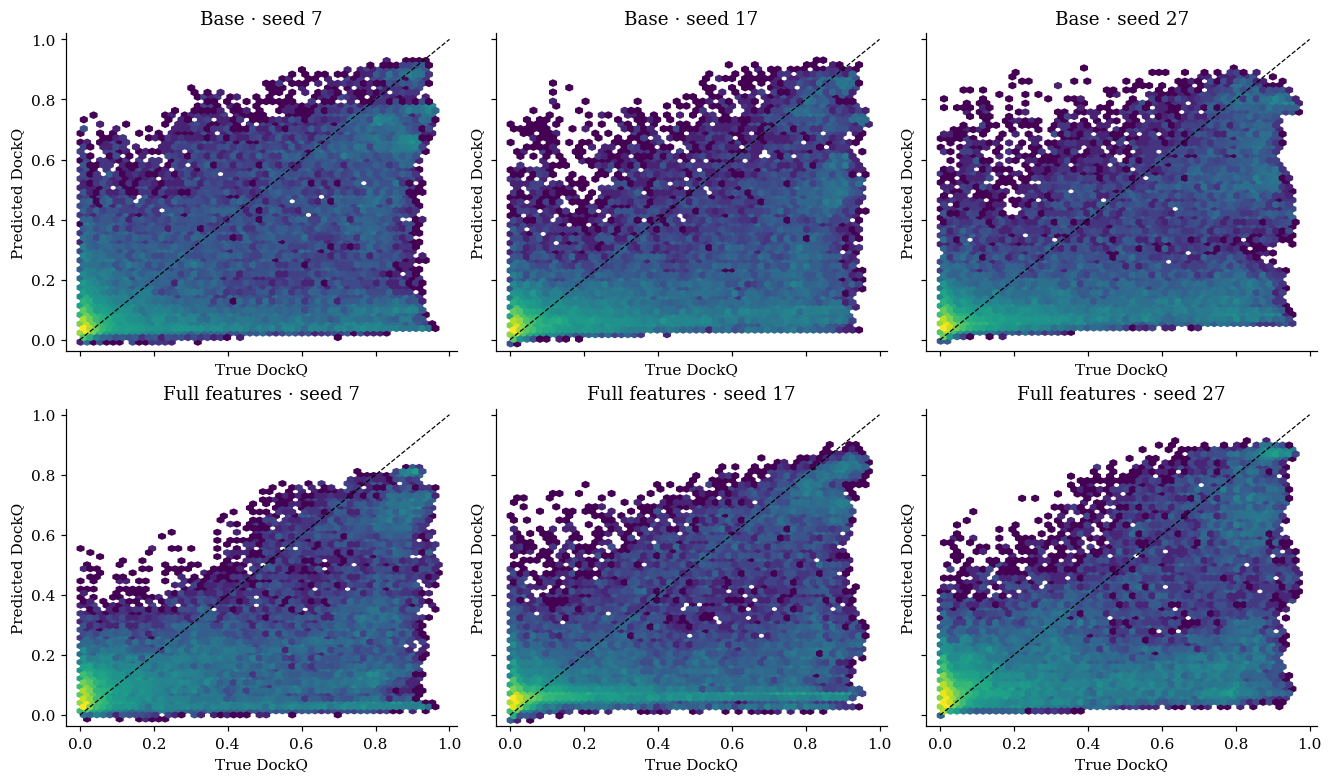

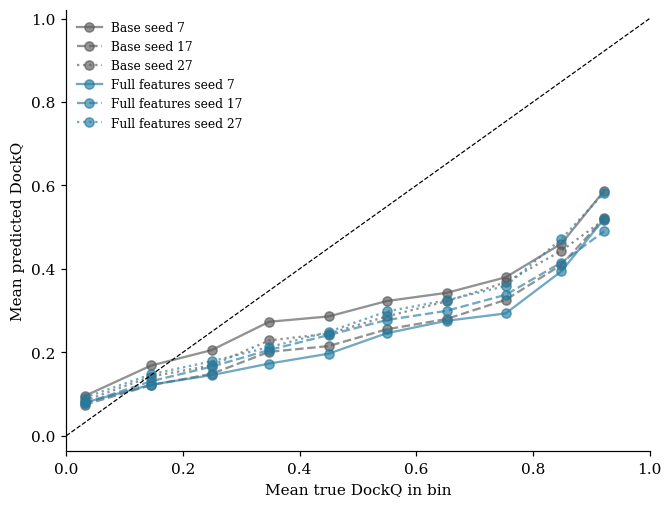

In [8]:
low=min(0.,min(f.predicted_target.min() for f in predictions.values()))-.02
high=max(1.,max(f.predicted_target.max() for f in predictions.values()))+.02
fig,axes=plt.subplots(2,3,figsize=(12,7),sharex=True,sharey=True,constrained_layout=True)
for row,c in enumerate(CONFIGS):
    for col,s in enumerate(SEEDS):
        ax=axes[row,col];f=predictions[c,s]
        ax.hexbin(f.true_target,f.predicted_target,gridsize=55,bins='log',mincnt=1,cmap='viridis',rasterized=True)
        ax.plot([0,1],[0,1],'k--',lw=.8)
        ax.set(xlim=(low,high),ylim=(low,high),xlabel='True DockQ',ylabel='Predicted DockQ',title=f'{LABELS[c]} · seed {s}')
savefig(fig,'observed_predicted_all_runs')
calibration=[]
for (c,s),f in predictions.items():
    for interval,g in f.groupby(pd.cut(f.true_target,np.linspace(0,1,11),include_lowest=True),observed=True):
        calibration.append(dict(config=c,seed=s,bin=str(interval),n=len(g),true_mean=g.true_target.mean(),
            predicted_mean=g.predicted_target.mean(),bias=(g.predicted_target-g.true_target).mean()))
calibration=pd.DataFrame(calibration);export(calibration,'true_dockq_bins')
fig,ax=plt.subplots(figsize=(6,4.5),constrained_layout=True)
for c in CONFIGS:
    for i,s in enumerate(SEEDS):
        g=calibration[(calibration.config==c)&(calibration.seed==s)]
        ax.plot(g.true_mean,g.predicted_mean,color=COLORS[c],marker='o',alpha=.65,ls=['-','--',':'][i],label=f'{LABELS[c]} seed {s}')
ax.plot([0,1],[0,1],'k--',lw=.8)
ax.set(xlabel='Mean true DockQ in bin',ylabel='Mean predicted DockQ',xlim=(0,1),ylim=(low,high))
ax.legend(fontsize=8);savefig(fig,'binned_prediction_bias')

## Top-ranked candidate selection

Good correlation across all decoys can coexist with poor top-1 selection. These curves summarize the best true DockQ among the top *k* predictions for each target, averaged equally across targets. The random reference applies only to selecting **one** structure; the oracle shows the best available structure per target.

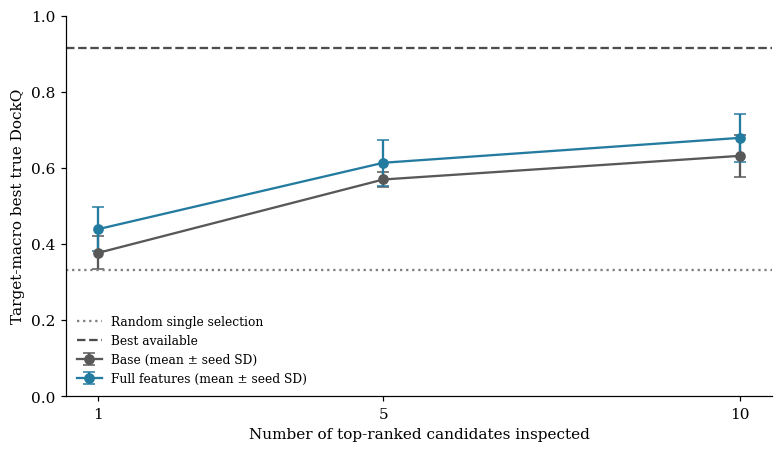

spearman          top1          top5        oracle        regret       
config     base   full   base   full   base   full   base   full   base   full
target                                                                        
1acb      0.681  0.804  0.423  0.739  0.509  0.877  0.924  0.924  0.501  0.185
1avx      0.699  0.902  0.036  0.637  0.269  0.838  0.910  0.910  0.874  0.273
1buh      0.603  0.621  0.075  0.239  0.491  0.550  0.905  0.905  0.830  0.666
1fle      0.766  0.668  0.227  0.100  0.249  0.358  0.925  0.925  0.698  0.825
1gla      0.136  0.171  0.010  0.008  0.024  0.127  0.931  0.931  0.921  0.923
1m10      0.721  0.643  0.386  0.379  0.627  0.584  0.919  0.919  0.533  0.540
1r0r      0.872  0.908  0.595  0.599  0.830  0.903  0.955  0.955  0.360  0.356
1r8o      0.886  0.893  0.756  0.871  0.869  0.922  0.944  0.944  0.188  0.073
1wmh      0.495  0.212  0.216  0.027  0.310  0.333  0.955  0.955  0.739  0.928
1xg2      0.411  0.618  0.106  0.166  0.156  0.384  0.935  0.935  0.829  0.769
1zhh      0.433  0.687  0.071  0.450  0.339  0.703  0.932  0.932  0.861  0.482
2ayo      0.795  0.858  0.648  0.738  0.715  0.811  0.863  0.863  0.215  0.125
2c0l      0.812  0.367  0.292  0.047  0.400  0.105  0.921  0.921  0.629  0.874
2fhz      0.884  0.867  0.748  0.873  0.891  0.943  0.971  0.971  0.223  0.098
2fju      0.338  0.137  0.013  0.004  0.475  0.389  0.891  0.891  0.878  0.887
2sic      0.829  0.879  0.678  0.603  0.732  0.638  0.933  0.933  0.255  0.330
3fpn      0.708  0.645  0.242  0.212  0.764  0.513  0.843  0.843  0.601  0.631
3sgb      0.915  0.957  0.768  0.877  0.884  0.899  0.923  0.923  0.155  0.046
3wdg      0.832  0.839  0.613  0.783  0.841  0.846  0.927  0.927  0.314  0.144
4hwi      0.104 -0.240  0.007  0.005  0.049  0.048  0.943  0.943  0.936  0.938
4qjf      0.929  0.918  0.798  0.787  0.833  0.842  0.900  0.900  0.102  0.113
4u1c      0.614  0.469  0.244  0.084  0.596  0.209  0.838  0.838  0.594  0.754
5maw      0.921  0.923  0.672  0.797  0.893  0.887  0.923  0.923  0.251  0.126
5mu7      0.839  0.787  0.272  0.285  0.662  0.770  0.904  0.904  0.632  0.619
8enf      0.813  0.833  0.523  0.664  0.830  0.858  0.871  0.871  0.348  0.207

In [9]:
fig,ax=plt.subplots(figsize=(7,4),constrained_layout=True)
ks=[1,5,10]
for c in CONFIGS:
    values=np.array([[metrics.loc[(metrics.config==c)&(metrics.seed==s),f'top{k}'].iloc[0] for k in ks] for s in SEEDS])
    ax.errorbar(ks,values.mean(0),yerr=values.std(0,ddof=1),color=COLORS[c],marker='o',capsize=4,label=LABELS[c]+' (mean ± seed SD)')
ax.axhline(metrics.random.iloc[0],ls=':',color='0.5',label='Random single selection')
ax.axhline(metrics.oracle.iloc[0],ls='--',color='0.3',label='Best available')
ax.set(xticks=ks,xlabel='Number of top-ranked candidates inspected',ylabel='Target-macro best true DockQ',ylim=(0,1))
ax.legend(fontsize=8);savefig(fig,'top_k_selection')
selection_table=per_target.groupby(['config','target'])[['spearman','top1','top5','oracle','regret']].mean().unstack('config')
display(selection_table.round(3))
selection_table.to_csv(EXPORT/'selection_by_target.csv')

## Target-by-target prediction panels

Choose a seed to compare base and full predictions for all held-out targets. Each title reports the within-target Spearman correlations. Common axes expose target-specific calibration failures. The plots use all available predictions, with rasterized points in PDF exports.

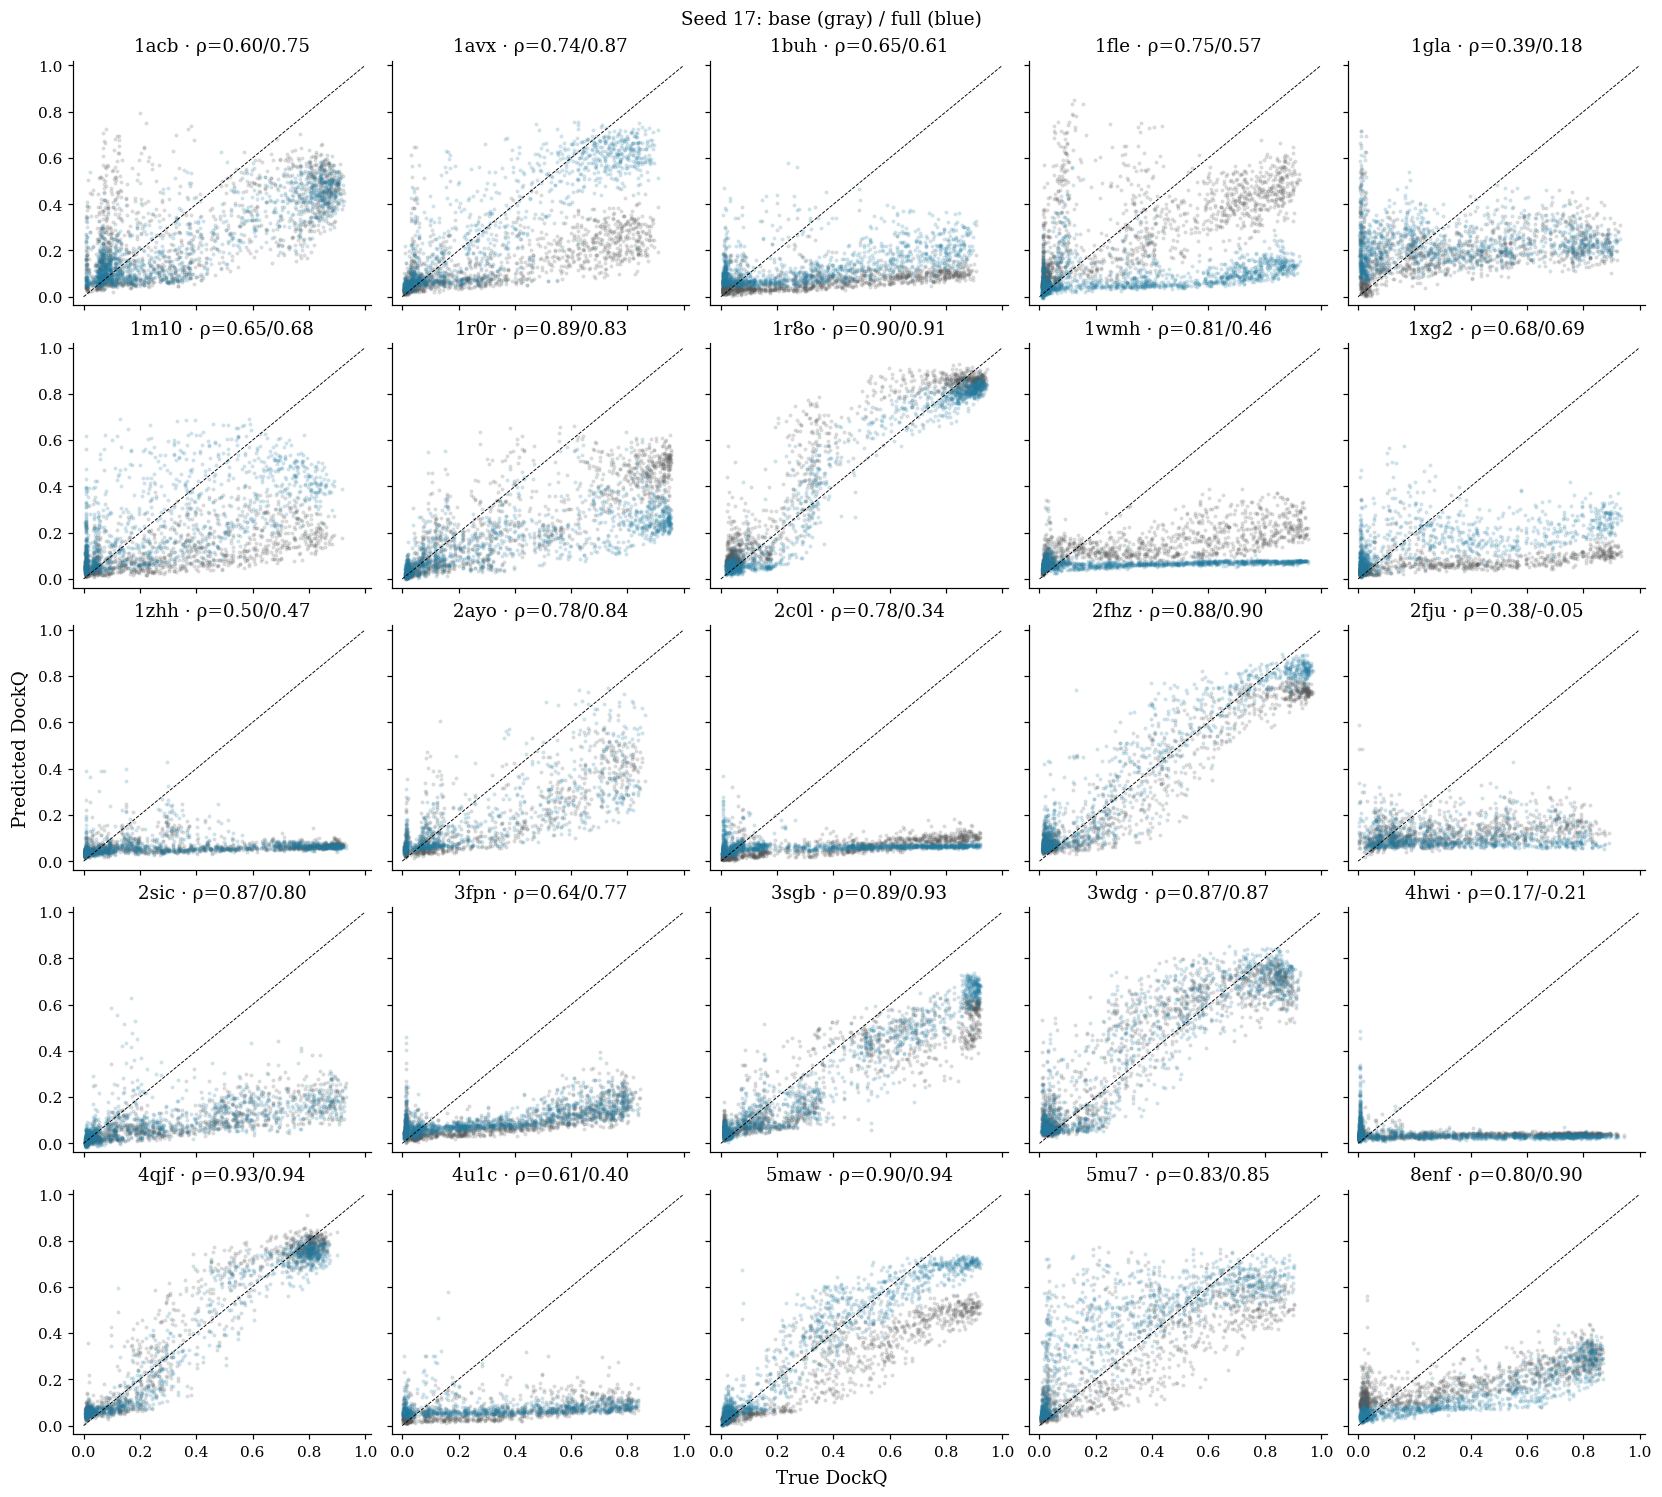

In [10]:
PANEL_SEED=17
targets=sorted(reference.target_id.unique())
fig,axes=plt.subplots(int(np.ceil(len(targets)/5)),5,figsize=(15,2.7*int(np.ceil(len(targets)/5))),sharex=True,sharey=True,constrained_layout=True)
for ax,t in zip(axes.flat,targets):
    rhos=[]
    for c in CONFIGS:
        f=predictions[c,PANEL_SEED];g=f[f.target_id==t]
        ax.scatter(g.true_target,g.predicted_target,s=3,alpha=.15,color=COLORS[c],rasterized=True,label=LABELS[c])
        rhos.append(correlation(g.true_target,g.predicted_target,True))
    ax.plot([0,1],[0,1],'k--',lw=.6)
    ax.set(title=f'{t} · ρ={rhos[0]:.2f}/{rhos[1]:.2f}',xlim=(low,high),ylim=(low,high))
for ax in list(axes.flat)[len(targets):]:ax.set_visible(False)
fig.supxlabel('True DockQ');fig.supylabel('Predicted DockQ')
fig.suptitle(f'Seed {PANEL_SEED}: base (gray) / full (blue)')
savefig(fig,f'prediction_panels_seed{PANEL_SEED}')

## Optional three-seed ensemble

Averaging predictions is a **different predictor** from averaging metrics across training runs. This exploratory calculation averages all three seeds equally, without choosing a seed on test performance. It should not replace the individual-run comparison above.

In [11]:
ensemble_rows=[]
for c in CONFIGS:
    f=predictions[c,SEEDS[0]].copy()
    f['predicted_target']=np.mean([predictions[c,s].predicted_target.to_numpy() for s in SEEDS],axis=0)
    target_rows=[]
    for t,g in f.groupby('target_id'):
        y,p=g.true_target.to_numpy(),g.predicted_target.to_numpy()
        order=np.argsort(-p,kind='stable')
        target_rows.append(dict(mse=np.mean((p-y)**2),rho=correlation(y,p,True),top1=y[order[0]],top5=y[order[:5]].max()))
    t=pd.DataFrame(target_rows)
    ensemble_rows.append(dict(config=c,rmse=np.sqrt(np.mean((f.predicted_target-f.true_target)**2)),
        macro_mse=t.mse.mean(),macro_spearman=t.rho.mean(),top1=t.top1.mean(),top5=t.top5.mean()))
ensemble=pd.DataFrame(ensemble_rows)
display(ensemble.round(4));export(ensemble,'three_seed_ensemble')

,config,rmse,macro_mse,macro_spearman,top1,top5
0,base,0.2732,0.0754,0.7103,0.4158,0.5995
1,full,0.2731,0.0748,0.6897,0.4452,0.5915


## Readout and interpretation limits

The summary below is generated from the current inputs. Seed SD and target-bootstrap uncertainty answer different questions. With only three seeds and one fixed target split, neither establishes robustness to a different train/test split. The full-feature comparison changes multiple inputs together, and adaptive weighting is shared by both groups: neither the benefit of Voronoi area alone nor the causal effect of loss weighting is isolated.

In [12]:
means=metrics.groupby('config').mean(numeric_only=True)
mse_row=paired.set_index('metric').loc['mse']
relative=100*(means.loc['base','macro_mse']-means.loc['full','macro_mse'])/means.loc['base','macro_mse']
selected_epochs=', '.join(f"{r.config} seed {r.seed}: {r.checkpoint_epoch}" for r in inventory.itertuples())
readout=f"""**Full versus base, averaged over three seeds:**

- Target-macro MSE: **{means.loc['base','macro_mse']:.4f} → {means.loc['full','macro_mse']:.4f}** ({relative:+.1f}% reduction).
- Paired MSE improvement: **{mse_row.mean_improvement:.4f}**, target-bootstrap 95% interval **[{mse_row.ci95_low:.4f}, {mse_row.ci95_high:.4f}]**.
- Within-target Spearman: **{means.loc['base','macro_spearman']:.3f} → {means.loc['full','macro_spearman']:.3f}**.
- Top-1 true DockQ: **{means.loc['base','top1']:.3f} → {means.loc['full','top1']:.3f}**; random single-selection reference **{means.loc['base','random']:.3f}**.
- Selected checkpoints: {selected_epochs}.

The raw training losses and validation curves are more informative than the adaptive weighted total alone. Use the validation-selected predictions as saved; do not pick a later epoch or favorable seed based on this test analysis.
"""
display(Markdown(readout))
(EXPORT/'readout.md').write_text(readout)
print('Saved CSV tables and PNG/PDF figures to',EXPORT)

**Full versus base, averaged over three seeds:**

- Target-macro MSE: **0.0795 → 0.0806** (-1.4% reduction).
- Paired MSE improvement: **-0.0011**, target-bootstrap 95% interval **[-0.0128, 0.0118]**.
- Within-target Spearman: **0.681 → 0.655**.
- Top-1 true DockQ: **0.377 → 0.439**; random single-selection reference **0.331**.
- Selected checkpoints: base seed 7: 1, base seed 17: 1, base seed 27: 1, full seed 7: 6, full seed 17: 1, full seed 27: 6.

The raw training losses and validation curves are more informative than the adaptive weighted total alone. Use the validation-selected predictions as saved; do not pick a later epoch or favorable seed based on this test analysis.


Saved CSV tables and PNG/PDF figures to /scratch/PPI-graph_autoencoder/gate_run/seed_replicates_analysis
